### Kategoria III: Chemia kwantowa (Qiskit Nature)
### Projekt 13: Model Isinga dla ferromagnetyzmu

## 1.Wprowadzenie

"Wyobraźmy sobie pewną strukturę złożoną z elektronów. Może być to łańcuch, może być to sieć, najważniejsza aby to była sieć krystaliczna. Do takiego modelu wprowadźmy zewnętrzne odziaływanie magnetyczne i zadajmy następujące pytanie: Dla jakiego ustawienia spinów elektronów, energia całego układu osiągnie najmniejszą wartość? 

Co do tego mają spiny? Przecież elektron to elektron, odpycha się Culombowsko. Nie zapominajmy jednak o zakazie Pauliego!

Także podsumowując: nasz model charakteryzują 4 elementy:

- Sieć krystaliczna elektronów
- Dwie wartości spinu
- Lokalność oddziaływania, czyli oddziaływanie elektronów na siebie zawęża się tylko do sąsiada elektronu
- Wpływ pola zewnętrznego, czyli tutaj konkretnie pola magnetycznego

## 2.Hamiltonian Isinga 
Hamiltonian Isinga reprezentuje energię w modelu:

$$ H = -J \sum_{\langle i,j \rangle}{Z_i Z_j} - h\sum_{i}{Z_i}$$

gdzie:

- $ J $ to energia oddziaływań między elektronami 
- $ h $ to energia oddziaływań elektronów z polem zewnętrznym

Czyli analogicznie:

- $ -J \sum_{\langle i,j \rangle}{Z_i Z_j}$ to całkowita energia oddziaływań między elektronami
- $ -h\sum_{i}{Z_i} $ to całkowita energia oddziaływań elektronów z polem zewnętrznym

Warto podkreślić, że ${\langle i,j \rangle}$ oznacza najbliższych sąsiadów, a $Z_i $ i $ Z_j $ to operatory spinu o wartościach 1 i -1.

Osobom, które mają wątpliwość, dlaczego szukamy najmniejszej energii spieszę z wyjaśnieniem - dla największej stabilności układu sieci. Jak jej szukamy? Tutaj mamy do wyboru parę metod, moim celem będzie ich omówienie i porównanie.

## 3. Magnetyzacja

Zanim jednak zaczniemy szukać energii, wprowadźmy jeszcze jeden parametr, zależny od J i h, a w niektórych modelach od T, czyli magnetyzację. Opisuje ona średni moment magnetyczny układu i wyraża się wzorem:

$$M = \frac{1}{N} \sum_{i=1}^{N} \sigma_i$$

gdzie $ M \in [-1,1] $ 
Co oznacza? W skrócie jak bardzo spiny są poukładane.

Zacznijmy od wgrania bibliotek

In [167]:
import numpy as np
import matplotlib.pyplot as plt

from qiskit.quantum_info import SparsePauliOp, Statevector
from qiskit.circuit.library import TwoLocal

from qiskit_algorithms import VQE
from qiskit_algorithms.optimizers import SLSQP
from qiskit_algorithms import NumPyMinimumEigensolver
from qiskit.primitives import StatevectorEstimator
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)

import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "notebook_connected"

### Jednowymiarowy model Isinga

Na początku omówmy model, w którym elektrony są ustawione w łańcuch krystaliczny.

Na samym początku ustalimy jak będą wyglądały hamiltoniany dla 8 spinów przy różnych wartościach J i h.

In [168]:
# Model Isinga 1D dla 8 spinów

def create_ising_hamiltonian_1d(num_spins, J, h):
    pauli_list = []

    # Sprzężenia między sąsiednimi spinami
    for i in range(num_spins - 1):
        z_term = 'I' * i + 'ZZ' + 'I' * (num_spins - i - 2)
        pauli_list.append((z_term, -J))

    # Pole zewnętrzne dla każdego spinu
    for i in range(num_spins):
        z_term = 'I' * i + 'Z' + 'I' * (num_spins - i - 1)
        pauli_list.append((z_term, -h))

    return SparsePauliOp.from_list(pauli_list)

J = [-2, -1.5, -1, -0.5, -0.2, -0.1, 0, 0.1, 0.2, 0.5, 1, 1.5, 2 ]  # Siła sprzężenia
h = [-2, -1.5, -1, -0.5, -0.2, -0.1, 0, 0.1, 0.2, 0.5, 1, 1.5, 2 ]  # Pole zewnętrzne
num_spins = 8

hamiltonian_list_8_spins = []

for j in J:
    for k in h:
        if j == 0 and k == 0:
            continue
        # Dla J=0 i h=0 model nie ma sensu
        hamiltonian = create_ising_hamiltonian_1d(8, j, k)
        hamiltonian_list_8_spins.append(((8, j, k), hamiltonian))
num_qubits_8_spins = hamiltonian.num_qubits


### Podejście kwantowe/klasyczne

Algorytmem o podejściu kwantowym, który świetnie nadaje się do wyliczenia energii podstawowej jest VQE. Wyliczymy od razu też magnetyzację.

Jedno bardzo ważne założenie! Tutaj zakładamy, że układ jest izolowany i działa przy $T=0K$. To będzie ważne dla dalszego badania modelu Isinga za pomocą klasycznego podejścia.

In [145]:
vqe_results = []

for i in hamiltonian_list_8_spins:
    ansatz_ising_1d = TwoLocal(
        num_qubits=num_qubits_8_spins,
        rotation_blocks='ry',
        entanglement_blocks='cx',
        entanglement='linear',  
        reps=2
    )
    # Definiujemy Ansatz w pętli, ponieważ VQE użyłoby parametrów z poprzedniego Ansatzu, co mogłoby doprowadzić do pogorszenia się wyników
    estimator = StatevectorEstimator() 
    optimizer = SLSQP(maxiter=1000)
    vqe_ising_1d = VQE(estimator, ansatz_ising_1d, optimizer)

    hamiltonian_ising_1d = i[1]
    result_ising_1d = vqe_ising_1d.compute_minimum_eigenvalue(hamiltonian_ising_1d)
    # Wyciągnięcie stanu i obliczenie magnetyzacji
    optimal_params = result_ising_1d.optimal_parameters
    optimal_circuit = ansatz_ising_1d.assign_parameters(optimal_params)
    state = Statevector.from_instruction(optimal_circuit)
    
    # Obliczenie magnetyzacji jako średnia wartość spinu
    probs = state.probabilities_dict()
    magnetyzacja = 0
    for bitstring, prob in probs.items():
        spins = [1 if b == '0' else -1 for b in bitstring]
        magnetyzacja += prob * np.mean(spins)
    
    vqe_results.append((i[0][1], i[0][2], result_ising_1d.eigenvalue.real, magnetyzacja))

Bad pipe message: %s [b' 10.0; Win64; x64; rv:147.0) Gecko/20100101 Firefox/147.0\r\nAccept: text/html,']
Bad pipe message: %s [b'plication/xhtml+xml,application/xml;q=0.9,*/*;q=0.8\r\nAccept-Language: pl,en-US;q=0.9,en;q=0.8\r\nA']
Bad pipe message: %s [b'ept-Encoding: gzip, deflate, br, zstd\r\nConnection: keep-alive\r\nUpgrade-Insecure-Requests: 1\r\nSec-F', b'ch-Dest: document\r\nSec-Fetch-Mode: navigate\r\nSec-Fetch-Site: none\r\nSec-Fetch-User: ?1\r\nPriority: u=0']


Zróbmy wykres zależności energii od J i h.

In [169]:
J_vals = [x[0] for x in vqe_results]
h_vals = [x[1] for x in vqe_results]
energies = [x[2] for x in vqe_results]

fig = go.Figure(data=[go.Mesh3d(
    x=J_vals,
    y=h_vals,
    z=energies,
    intensity=energies,
    colorscale='Viridis',
    opacity=0.8,
    showscale=True
)])

fig.update_layout(
    title='VQE - energia (N=8)',
    scene=dict(
        xaxis_title='J (Sprzężenie)',
        yaxis_title='h (Pole)',
        zaxis_title='Energia'
    ),
    width=900,
    height=700,
    margin=dict(l=0, r=0, b=0, t=40)
)

fig.show()

In [171]:
J_vals = [x[0] for x in vqe_results]
h_vals = [x[1] for x in vqe_results]
magnetism = [x[3] for x in vqe_results]

fig = go.Figure(data=[go.Mesh3d(
    x=J_vals,
    y=h_vals,
    z=magnetism,
    intensity=energies,
    colorscale='Viridis',
    opacity=0.8,
    showscale=True
)])

fig.update_layout(
    title='VQE - magnetyzacja (N=8)',
    scene=dict(
        xaxis_title='J',
        yaxis_title='h',
        zaxis_title='Magnetyzacja'
    ),
    width=900,
    height=700,
    margin=dict(l=0, r=0, b=0, t=40)
)

fig.show()

#### Przykładowe pokazanie spinów

Najbardziej prawdopodobna konfiguracja (bitstring): 10101111
Prawdopodobieństwo tego stanu: 0.4447


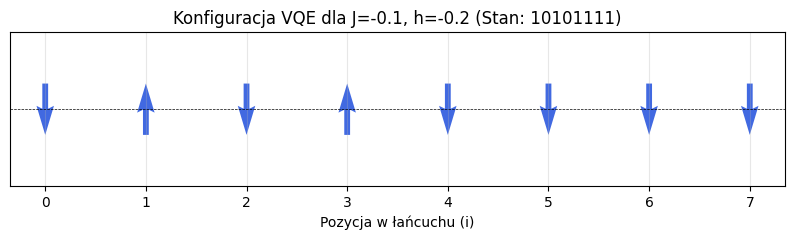

In [170]:
J = -0.1
h = -0.2

example_hamiltonian = create_ising_hamiltonian_1d(8, J, h)
num_qubits_8_spins = hamiltonian.num_qubits

ansatz_ising_1d = TwoLocal(
        num_qubits=num_qubits_8_spins,
        rotation_blocks='ry',
        entanglement_blocks='cx',
        entanglement='linear',  
        reps=2
    )
estimator = StatevectorEstimator() 
optimizer = SLSQP(maxiter=1000)
vqe_ising_1d = VQE(estimator, ansatz_ising_1d, optimizer)

hamiltonian_ising_1d = example_hamiltonian
result_ising_1d = vqe_ising_1d.compute_minimum_eigenvalue(hamiltonian_ising_1d)

optimal_params = result_ising_1d.optimal_parameters
optimal_circuit = ansatz_ising_1d.assign_parameters(optimal_params)

state = Statevector.from_instruction(optimal_circuit)

probs = state.probabilities_dict()
best_bitstring = max(probs, key=probs.get)

print(f"Najbardziej prawdopodobna konfiguracja (bitstring): {best_bitstring}")
print(f"Prawdopodobieństwo tego stanu: {probs[best_bitstring]:.4f}")

def plot_ising_spins(bitstring, J, h):
    spins = [1 if b == '0' else -1 for b in bitstring]
    N = len(spins)
    
    plt.figure(figsize=(10, 2))
    plt.quiver(range(N), [0]*N, [0]*N, spins, 
               pivot='mid', color='royalblue', scale=1.0, scale_units='xy')
    
    plt.title(f"Konfiguracja VQE dla J={J}, h={h} (Stan: {bitstring})")
    plt.xlabel("Pozycja w łańcuchu (i)")
    plt.xticks(range(N))
    plt.yticks([])
    plt.ylim(-1.5, 1.5)
    plt.axhline(0, color='black', linewidth=0.5, linestyle='--')
    plt.grid(axis='x', alpha=0.3)
    plt.show()

plot_ising_spins(best_bitstring, J, h)

## Podejście klasyczne

### Metoda dokładnej diagonalizacji

Metoda dokładnej diagonalizacji polega na znalezieniu wartości własnych i wektorów własnych macierzy Hamiltonianu. Dzięki temu możemy poznać dokładną alegbraicznie wartość energii podstawowej. Pozytywną stroną takiego rozwiązania są bardzo dobre wyniki dla małych układów. Oczywiście narzucającą się wadą jest brak rosnąca w sposób wykładniczy ilość operacji zależna od wielkości sieci, przez to dla gigantycznych sieci jest metoda ta jest bezużyteczna

In [172]:
def exact_diagonalization(lista_hamiltonianow):
    results = []
    solver = NumPyMinimumEigensolver()
    
    for item in lista_hamiltonianow:
        parametry = item[0]
        hamiltonian = item[1]
        
        result = solver.compute_minimum_eigenvalue(hamiltonian)
        energia = result.eigenvalue.real
        
        eigenvector = result.eigenstate
        probs = eigenvector.probabilities_dict()
        
        magnetyzacja = 0
        for bitstring, prob in probs.items():
            spins = [1 if b == '0' else -1 for b in bitstring]
            magnetyzacja += prob * np.mean(spins)
        
        results.append((parametry[1], parametry[2], energia, magnetyzacja))
        
    return results

exact_diagonalization_8 = exact_diagonalization(hamiltonian_list_8_spins)

In [173]:
J_ed = [x[0] for x in exact_diagonalization_8]
h_ed = [x[1] for x in exact_diagonalization_8]
energies_ed = [x[2] for x in exact_diagonalization_8]

fig_ed = go.Figure(data=[go.Mesh3d(
    x=J_ed,
    y=h_ed,
    z=energies_ed,
    intensity=energies_ed,
    colorscale='Inferno',  
    opacity=1.0,
    showscale=True
)])

fig_ed.update_layout(
    title='ED - energia (N=8)',
    scene=dict(
        xaxis_title='J (Sprzężenie)',
        yaxis_title='h (Pole)',
        zaxis_title='Energia'
    ),
    width=900,
    height=700,
    margin=dict(l=0, r=0, b=0, t=40)
)

fig_ed.show()

In [175]:
J_ed = [x[0] for x in exact_diagonalization_8]
h_ed = [x[1] for x in exact_diagonalization_8]
magnetism = [x[3] for x in exact_diagonalization_8]

fig_ed = go.Figure(data=[go.Mesh3d(
    x=J_ed,
    y=h_ed,
    z=magnetism,
    intensity=energies_ed,
    colorscale='Inferno',  
    opacity=1.0,
    showscale=True
)])

fig_ed.update_layout(
    title='ED - magnetyzacja (N=8)',
    scene=dict(
        xaxis_title='J',
        yaxis_title='h',
        zaxis_title='Magnetyzacja'
    ),
    width=900,
    height=700,
    margin=dict(l=0, r=0, b=0, t=40)
)

fig_ed.show()

### Metoda Monte Carlo (Metropolis)

Nader często wracając z uczelni autem razem z kolegą stwierdzamy, że metoda Monte Carlo to jedna z najlepszych metod statystycznych, od liczenia całek oznaczonych do symulowania ruchu układów galaktycznych. W naszym przypadku polegać ona będzie na zmianach spinów elektronów i sprawdzeniu energii nie całego układu, ale elektronu na którym zadziałaliśmy i jego sąsiadów. Gwarantujemy przy tym brak wykładniczości, ale nie gwarantujemy dokładnych wyników (klasyczne Monte Carlo).

In [174]:
def metropolis_stan_podstawowy(N, J, h, iteracje=1000):
    spiny = np.random.choice([-1, 1], size=N)
    
    def calculate_E(s):
        # Oddziaływanie sąsiadów
        energia_J = -J * np.sum(s[:-1] * s[1:])
        # Oddziaływanie pola
        energia_h = -h * np.sum(s)
        return energia_J + energia_h

    aktualna_E = calculate_E(spiny)

    for _ in range(iteracje):
        # Wybieramy losowy spin i go odwracamy
        idx = np.random.randint(0, N)
        spiny[idx] *= -1
        nowa_E = calculate_E(spiny)

        if nowa_E <= aktualna_E:
            aktualna_E = nowa_E
        else:
            spiny[idx] *= -1
    
    magnetyzacja = np.mean(spiny)
    
    return aktualna_E, magnetyzacja

wyniki_mc_8 = []
for item in hamiltonian_list_8_spins:
    parametry = item[0]  
    N, J, h = parametry
    
    energia_mc, magnetyzacja_mc = metropolis_stan_podstawowy(N, J, h)
    wyniki_mc_8.append((J, h, energia_mc, magnetyzacja_mc))

In [176]:
J_mc = [x[0] for x in wyniki_mc_8]
h_mc = [x[1] for x in wyniki_mc_8]
energies_mc = [x[2] for x in wyniki_mc_8]

fig_mc = go.Figure(data=[go.Mesh3d(
    x=J_mc,
    y=h_mc,
    z=energies_mc,
    intensity=energies_mc,
    colorscale='Cividis',  
    opacity=1.0,
    showscale=True
)])

fig_mc.update_layout(
    title='Monte Carlo - energia (N=8)',
    scene=dict(
        xaxis_title='J (Sprzężenie)',
        yaxis_title='h (Pole)',
        zaxis_title='Energia'
    ),
    width=900,
    height=700,
    margin=dict(l=0, r=0, b=0, t=40)
)

fig_mc.show()

In [177]:
J_mc = [x[0] for x in wyniki_mc_8]
h_mc = [x[1] for x in wyniki_mc_8]
magnetism = [x[3] for x in wyniki_mc_8]

fig_mc = go.Figure(data=[go.Mesh3d(
    x=J_mc,
    y=h_mc,
    z=magnetism,
    intensity=energies_mc,
    colorscale='Cividis',  
    opacity=1.0,
    showscale=True
)])

fig_mc.update_layout(
    title='Monte Carlo - magnetyzacja (N=8)',
    scene=dict(
        xaxis_title='J (Sprzężenie)',
        yaxis_title='h (Pole)',
        zaxis_title='magnetyzacja'
    ),
    width=900,
    height=700,
    margin=dict(l=0, r=0, b=0, t=40)
)

fig_mc.show()

Jak widzimy dla energii podstawowych dostaliśmy podobne wykresy, chociaż przy Metodzie Monte Carlo nie są one tak gładkie jak w przypadku ED. VQE wykonywało się bardzo długo z uwagi na długą optymalizację klasyczną, oraz liczbę parametrów, dlatego widać, że dla małych modeli nie jest optymalnym algorytmem.

Dla modelu Isinga możemy zdefiniować jeszcze jedną zmienną wpływającą na model. Będzie to temperatura. Możemy założyć, że układ nie jest izolowany i sprawdzić jak to wpłynie na model, a przede wszystkim na magnetyzację. Intuicja podpowiada, że im większa temperatura, tym większa entropia, tym mniejsza magnetyzacja. Sprawdźmy to!

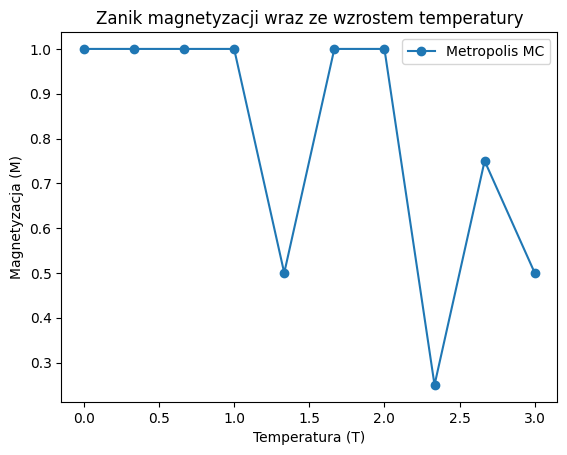

In [178]:
def metropolis_for_T(N, J, h, temperatures):
    results_M = []
    
    for T in temperatures:
        spins = np.random.choice([1, -1], size=N)
        beta = 1.0 / T if T > 0 else 1e10 # 1e10 ≈ β→∞ dla T=0 (układ zamrażamy)

        for _ in range(5000):
            idx = np.random.randint(0, N)
            dE = 2 * spins[idx] * (J * (spins[(idx-1)%N] + spins[(idx+1)%N]) + h) # Zmiana energii przy zmianie spinu
            
            if dE <= 0 or np.random.rand() < np.exp(-dE * beta):
                spins[idx] *= -1
        
        # Średnia magnetyzacja dla danej temperatury
        results_M.append(np.mean(spins))  
    
    return results_M

T_range = np.linspace(0, 3, 10)
M_values = metropolis_for_T(8, J=1, h=1, temperatures=T_range)

plt.plot(T_range, M_values, 'o-', label='Metropolis MC')
plt.title("Zanik magnetyzacji wraz ze wzrostem temperatury")
plt.xlabel("Temperatura (T)")
plt.ylabel("Magnetyzacja (M)")
plt.legend()
plt.show()

### Dwuwymiarowy model Isinga

Podobne badanie zróbmy dla modelu dwywymiarowego, tym razem bardziej skupimy się na wpływie temperatury w metodzie Monte Carlo

In [179]:
# Zbuduj Hamiltonian Isinga dla siatki 3x3

# Topologia:
# σ₀ --- σ₁ --- σ₂
#  |      |      |
# σ₃ --- σ₄ --- σ₅
#  |      |      |
# σ₆ --- σ₇ --- σ₈


def create_ising_hamiltonian_3x3(J, h):
    num_spins = 9  # 3x3=9
    width = 3
    pauli_list = []

    for row in range(3):
        for col in range(2):  
            i = row * width + col
            z_term = 'I' * i + 'ZZ' + 'I' * (num_spins - i - 2)
            pauli_list.append((z_term, -J))

    for row in range(2):  
        for col in range(3):
            i = row * width + col
            z_term = 'I' * i + 'Z' + 'I' * 3 + 'Z' + 'I' * (num_spins - i - 4)
            pauli_list.append((z_term, -J))

    # 3. Pole zewnętrzne (dla każdego spinu)
    for i in range(num_spins):
        z_term = 'I' * i + 'Z' + 'I' * (num_spins - i - 1)
        pauli_list.append((z_term, -h))

    return SparsePauliOp.from_list(pauli_list)

J = [-2, -1.5, -1, -0.5, -0.2, -0.1, 0, 0.1, 0.2, 0.5, 1, 1.5, 2 ]  # Siła sprzężenia
h = [-2, -1.5, -1, -0.5, -0.2, -0.1, 0, 0.1, 0.2, 0.5, 1, 1.5, 2 ]  # Pole zewnętrzne

hamiltonian_list_3x3 = []

for j in J:
    for k in h:
        if j == 0 and k == 0:
            continue
        
        hamiltonian = create_ising_hamiltonian_3x3(j, k)
        hamiltonian_list_3x3.append(((9, j, k), hamiltonian))

num_qubits_3x3 = hamiltonian.num_qubits

In [ ]:
vqe_results_2d = []

polaczenia = []
for r in range(3):
    for c in range(3):
        idx = r * 3 + c
        if c < 2: polaczenia.append([idx, idx + 1]) 
        if r < 2: polaczenia.append([idx, idx + 3]) 

for i in hamiltonian_list_3x3:
    ansatz_ising_2d = TwoLocal(
        num_qubits=num_qubits_3x3,
        rotation_blocks='ry',
        entanglement_blocks='cx',
        entanglement=polaczenia,  
        reps=2
    )
    estimator = StatevectorEstimator()
    optimizer = SLSQP(maxiter=100)
    vqe_ising_2d = VQE(estimator, ansatz_ising_2d, optimizer)

    hamiltonian_ising_2d = i[1]
    result_ising_2d = vqe_ising_2d.compute_minimum_eigenvalue(hamiltonian_ising_2d)
    
    optimal_params = result_ising_2d.optimal_parameters
    optimal_circuit = ansatz_ising_2d.assign_parameters(optimal_params)
    state = Statevector.from_instruction(optimal_circuit)
    
    probs = state.probabilities_dict()
    magnetyzacja = 0
    for bitstring, prob in probs.items():
        spins = [1 if b == '0' else -1 for b in bitstring]
        magnetyzacja += prob * np.mean(spins)
    
    vqe_results_2d.append((i[0][1], i[0][2], result_ising_2d.eigenvalue.real, magnetyzacja))

J=-2.00, h=-2.00 -> E=-26.000000
Liczba wywołań funkcji:     1069
J=-2.00, h=-1.50 -> E=-24.499999
Liczba wywołań funkcji:     865
J=-2.00, h=-1.00 -> E=-17.000000
Liczba wywołań funkcji:     607
J=-2.00, h=-0.50 -> E=-21.499999
Liczba wywołań funkcji:     1040
J=-2.00, h=-0.20 -> E=-15.800000
Liczba wywołań funkcji:     1039
J=-2.00, h=-0.10 -> E=-20.300000
Liczba wywołań funkcji:     1178
J=-2.00, h=0.00 -> E=-15.999998
Liczba wywołań funkcji:     722
J=-2.00, h=0.10 -> E=-19.900000
Liczba wywołań funkcji:     781
J=-2.00, h=0.20 -> E=-16.200000
Liczba wywołań funkcji:     1058
J=-2.00, h=0.50 -> E=-19.499999
Liczba wywołań funkcji:     754
J=-2.00, h=1.00 -> E=-19.000000
Liczba wywołań funkcji:     756
J=-2.00, h=1.50 -> E=-20.499999
Liczba wywołań funkcji:     894
J=-2.00, h=2.00 -> E=-22.000000
Liczba wywołań funkcji:     896
J=-1.50, h=-2.00 -> E=-21.000000
Liczba wywołań funkcji:     698
J=-1.50, h=-1.50 -> E=-19.500000
Liczba wywołań funkcji:     1035
J=-1.50, h=-1.00 -> E=-18.

In [180]:
J_vals_vqe = [x[0] for x in vqe_results_2d]
h_vals_vqe = [x[1] for x in vqe_results_2d]
energies_vqe = [x[2] for x in vqe_results_2d]

fig = go.Figure(data=[go.Mesh3d(
    x=J_vals_vqe,
    y=h_vals_vqe,
    z=energies_vqe,
    intensity=energies_vqe,
    colorscale='Viridis',
    opacity=0.8,
    showscale=True
)])

fig.update_layout(
    title='VQE - Energia',
    scene=dict(
        xaxis_title='J',
        yaxis_title='h',
        zaxis_title='Energia'
    ),
    width=900,
    height=700,
    margin=dict(l=0, r=0, b=0, t=40)
)

fig.show()

In [181]:
magnetism_vqe = [x[3] for x in vqe_results_2d]

fig = go.Figure(data=[go.Mesh3d(
    x=J_vals_vqe,
    y=h_vals_vqe,
    z=magnetism_vqe,
    intensity=energies_vqe,
    colorscale='Viridis',
    opacity=0.8,
    showscale=True
)])

fig.update_layout(
    title='VQE - Magnetyzacja',
    scene=dict(
        xaxis_title='J',
        yaxis_title='h',
        zaxis_title='Magnetyzacja'
    ),
    width=900,
    height=700,
    margin=dict(l=0, r=0, b=0, t=40)
)

fig.show()

In [182]:
def exact_diagonalization_3x3(lista_hamiltonianow):
    results = []
    solver = NumPyMinimumEigensolver()
    
    for item in lista_hamiltonianow:
        parametry = item[0]
        hamiltonian = item[1]
        
        result = solver.compute_minimum_eigenvalue(hamiltonian)
        energia = result.eigenvalue.real
        
        eigenvector = result.eigenstate
        probs = eigenvector.probabilities_dict()
        
        magnetyzacja = 0
        for bitstring, prob in probs.items():
            spins = [1 if b == '0' else -1 for b in bitstring]
            magnetyzacja += prob * np.mean(spins)
        
        results.append((parametry[1], parametry[2], energia, magnetyzacja))
        
    return results

exact_diagonalization_3x3 = exact_diagonalization_3x3(hamiltonian_list_3x3)

In [183]:
J_ed = [x[0] for x in exact_diagonalization_3x3]
h_ed = [x[1] for x in exact_diagonalization_3x3]
energies_ed = [x[2] for x in exact_diagonalization_3x3]

fig = go.Figure(data=[go.Mesh3d(
    x=J_ed,
    y=h_ed,
    z=energies_ed,
    intensity=energies_ed,
    colorscale='Inferno',
    opacity=1.0,
    showscale=True
)])

fig.update_layout(
    title='ED - Energia',
    scene=dict(
        xaxis_title='J',
        yaxis_title='h',
        zaxis_title='Energia'
    ),
    width=900,
    height=700,
    margin=dict(l=0, r=0, b=0, t=40)
)

fig.show()

In [184]:
magnetism_ed = [x[3] for x in exact_diagonalization_3x3]

fig = go.Figure(data=[go.Mesh3d(
    x=J_ed,
    y=h_ed,
    z=magnetism_ed,
    intensity=energies_ed,
    colorscale='Inferno',
    opacity=1.0,
    showscale=True
)])

fig.update_layout(
    title='ED - Magnetyzacja',
    scene=dict(
        xaxis_title='J',
        yaxis_title='h',
        zaxis_title='Magnetyzacja'
    ),
    width=900,
    height=700,
    margin=dict(l=0, r=0, b=0, t=40)
)

fig.show()

In [185]:
def metropolis_stan_podstawowy_2d(N, J, h, T=1.0, iteracje=1000):
    spiny = np.random.choice([-1, 1], size=N)
    
    def calculate_E_2d(s, width=3):
        energia = 0
        for i in range(N):
            if i % width < width - 1:
                energia -= J * s[i] * s[i + 1]
            if i < N - width:
                energia -= J * s[i] * s[i + width]
            energia -= h * s[i]
        return energia

    aktualna_E = calculate_E_2d(spiny)
    beta = 1.0 / T if T > 0 else 1e10

    for _ in range(iteracje):
        idx = np.random.randint(0, N)
        spiny_old = spiny[idx]
        spiny[idx] *= -1
        nowa_E = calculate_E_2d(spiny)
        
        dE = nowa_E - aktualna_E
        
        if dE <= 0 or np.random.rand() < np.exp(-dE * beta):
            aktualna_E = nowa_E
        else:
            spiny[idx] = spiny_old
    
    magnetyzacja = np.mean(spiny)
    return aktualna_E, magnetyzacja

wyniki_mc_3x3 = []
for item in hamiltonian_list_3x3:
    parametry = item[0]  
    N, J, h = parametry
    
    energia_mc, magnetyzacja_mc = metropolis_stan_podstawowy_2d(N, J, h)
    wyniki_mc_3x3.append((J, h, energia_mc, magnetyzacja_mc))

In [186]:
J_mc = [x[0] for x in wyniki_mc_3x3]
h_mc = [x[1] for x in wyniki_mc_3x3]
energies_mc = [x[2] for x in wyniki_mc_3x3]

fig = go.Figure(data=[go.Mesh3d(
    x=J_mc,
    y=h_mc,
    z=energies_mc,
    intensity=energies_mc,
    colorscale='Cividis',
    opacity=1.0,
    showscale=True
)])

fig.update_layout(
    title='MC - Energia',
    scene=dict(
        xaxis_title='J',
        yaxis_title='h',
        zaxis_title='Energia'
    ),
    width=900,
    height=700,
    margin=dict(l=0, r=0, b=0, t=40)
)

fig.show()

In [98]:
magnetism_mc = [x[3] for x in wyniki_mc_3x3]

fig = go.Figure(data=[go.Mesh3d(
    x=J_mc,
    y=h_mc,
    z=magnetism_mc,
    intensity=energies_mc,
    colorscale='Cividis',
    opacity=1.0,
    showscale=True
)])

fig.update_layout(
    title='MC - Magnetyzacja',
    scene=dict(
        xaxis_title='J',
        yaxis_title='h',
        zaxis_title='Magnetyzacja'
    ),
    width=900,
    height=700,
    margin=dict(l=0, r=0, b=0, t=40)
)

fig.show()

Porównajmy teraz bardziej zależność między magnetyzacją a temperaturą dla różnych J i h

In [187]:
# Porównanie M(T) dla różnych J i h w modelu 2D
fig_2d_comparison = go.Figure()

# Wybieramy kilka charakterystycznych kombinacji J i h
test_cases_2d = [
    (2.0, 0.0, "J=2.0, h=0.0 "),
    (1.0, 0.0, "J=1.0, h=0.0 "),
    (1.0, 0.5, "J=1.0, h=0.5 "),
    (1.0, 1.0, "J=1.0, h=1.0 "),
    (2.0, 2.0, "J=2.0, h=2.0 "),
    (0.5, 0.0, "J=0.5, h=0.0 "),
]

T_range_2d = np.linspace(0, 4.0, 30)  

for J_val, h_val, label in test_cases_2d:
    M_temp = metropolis_for_T(9, J_val, h_val, T_range_2d)
    fig_2d_comparison.add_trace(go.Scatter(
        x=T_range_2d,
        y=np.abs(M_temp),
        mode='lines+markers',
        name=label,
        line=dict(width=2)
    ))

fig_2d_comparison.update_layout(
    title='Zależność magnetyzacji od temperatury (Model 2D - 3x3)',
    xaxis_title='Temperatura (T)',
    yaxis_title='|Magnetyzacja| (|M|)',
    hovermode='x unified',
    height=600,
    width=1000
)

fig_2d_comparison.show()

### Wnioski

Analizując wykresy zależności magnetyzacji od temperatury dla modelu 2D, obserwujemy kilka istotnych zjawisk:

1. **Wpływ sprzężenia J**: Dla większych wartości J (silniejsze sprzężenie ferromagnetyczne) układ wykazuje znacznie większą odporność na wzrost temperatury. Magnetyzacja pozostaje wysoka nawet przy wyższych temperaturach.

2. **Rola pola zewnętrznego h**: Pole zewnętrzne działa stabilizująco na magnetyzację. Kombinacja dużych J i h (J=2.0, h=2.0) prowadzi do utrzymania silnej magnetyzacji nawet przy temperaturach bliskich 4K.

3. **Temperatura krytyczna**: Obserwujemy przejście fazowe - poniżej pewnej temperatury krytycznej (charakterystycznej dla każdego zestawu parametrów) magnetyzacja jest wysoka i stabilna, powyżej niej szybko maleje z entropią.

4. **Wymiarowość układu**: Model 2D wykazuje bardziej ostrą przejście fazowe niż model 1D, co jest zgodne z teorią przejść fazowych (model 2D Isinga ma rzeczywiste przejście fazowe, model 1D nie).

**Wniosek praktyczny**: Temperatura nie jest sprzymierzeńcem w modelu Isinga. Za wszelką cenę powinniśmy dążyć do jak najmniejszych temperatur dla stabilnego i przewidywalnego modelowania sieci spinów.

## Podsumowanie

Zobaczyliśmy na czym polega model Isinga i próbowaliśmy zrozumieć na czym polega od strony matematycznej. Wyjaśniliśmy czym są parametry J i h, dlaczego szukamy najmniejszej energii oraz wyjaśniliśmy jak do tego ma się magnetyzm.

Poznaliśmy **3 algorytmy** pomagające obliczyć energie podstawową:
- VQE (kwantowe)
- Exact Diagonalization (dokładne)
- Monte Carlo Metropolis (efektywne)

Zwizualizowaliśmy je na wykresach 3D pokazujących krajobrazy energii i magnetyzacji.

Pokazaliśmy jak wygląda rzeczywisty układ spinów - od małych perturbacji po całkowite odwrócenia.

Na koniec dołączyliśmy do modelu temperaturę i sprawdzaliśmy jak się zachowuje magnetyzacja. Okazało się, że temperatura definitywnie nie sprzyja stabilności - im wyższa temperatura, tym więcej chaosu w układzie.

### Autor: Sebastian Półtorak

### Bibliografia

[1] Tulewicz P. Qiskit Nature - VQE i chemia kwantowa. Materiały dydaktyczne do zajęć nr 6 (plik .ipynb), rok akademicki 2025/2026.

[2] Kawecka-Magiera, B. (2006). 'Własności magnetyczne układów niejednorodnych w modelu Isinga'. Rozprawa doktorska, Wydział Fizyki i Informatyki Stosowanej, Akademia Górniczo-Hutnicza, Kraków.

[3] Wikipedia Contributors (2024). 'Ising Model'. Wikipedia, The Free Encyclopedia. Dostęp: https://en.wikipedia.org/wiki/Ising_model

[4] Wikipedia Contributors (2024). 'Metropolis–Hastings algorithm'. Wikipedia, The Free Encyclopedia. Dostęp: https://en.wikipedia.org/wiki/Metropolis%E2%80%93Hastings_algorithm